In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

# Paths — going up one level from notebooks/ to reach data/
DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")

# Load AGV data
agv_history = pd.read_csv(DATA_RAW / "robot_runs_history.csv")
agv_current = pd.read_csv(DATA_RAW / "robot_runs_current.csv")

# Load CMAPSS
cmapss = pd.read_csv(DATA_PROCESSED / "cmapss_normalized.csv")

# Load processed files
with open(DATA_PROCESSED / "fleet_baselines.json") as f:
    baselines = json.load(f)
with open(DATA_PROCESSED / "mtbf_mttr.json") as f:
    mtbf_mttr = json.load(f)
with open(DATA_PROCESSED / "engine_profiles.json") as f:
    engine_profiles = json.load(f)

print("AGV history shape:", agv_history.shape)
print("AGV current shape:", agv_current.shape)
print("CMAPSS shape:", cmapss.shape)
print("Baselines:", list(baselines.keys()))

AGV history shape: (85800, 11)
AGV current shape: (3000, 11)
CMAPSS shape: (20631, 27)
Baselines: ['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R9', 'R10']


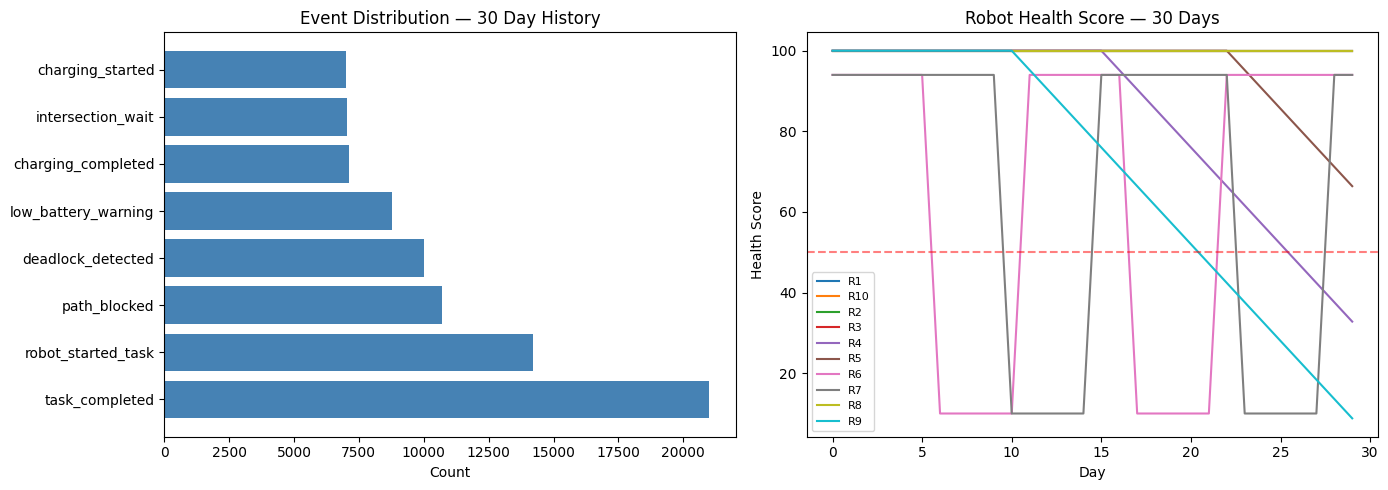

Chart saved


In [5]:
# Event distribution across the whole fleet
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Event type counts
event_counts = agv_history["event"].value_counts()
axes[0].barh(event_counts.index, event_counts.values, color="steelblue")
axes[0].set_title("Event Distribution — 30 Day History")
axes[0].set_xlabel("Count")

# Average health score per robot over time
robot_health = agv_history.groupby(["robot_id", "day"])["health_score"].mean().reset_index()
for robot_id in sorted(agv_history["robot_id"].unique()):
    data = robot_health[robot_health["robot_id"] == robot_id]
    axes[1].plot(data["day"], data["health_score"], label=robot_id, linewidth=1.5)

axes[1].set_title("Robot Health Score — 30 Days")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Health Score")
axes[1].legend(loc="lower left", fontsize=8)
axes[1].axhline(y=50, color="red", linestyle="--", alpha=0.5, label="Critical threshold")

plt.tight_layout()
plt.savefig("../data/processed/fleet_health_overview.png", dpi=150)
plt.show()
print("Chart saved")

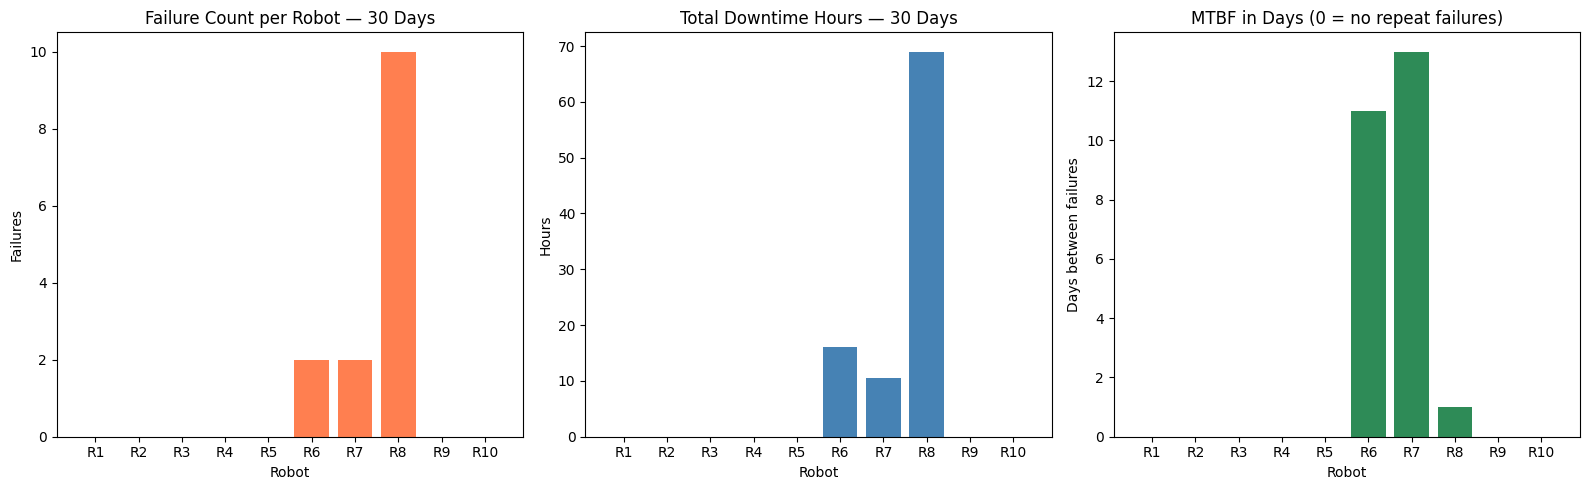

Chart saved to docs/


In [6]:
# Visualize MTBF and downtime per robot
robots = list(mtbf_mttr.keys())
failure_counts = [mtbf_mttr[r]["failure_count"] for r in robots]
downtime_hours = [mtbf_mttr[r]["total_downtime_hours"] for r in robots]
mtbf_values = [mtbf_mttr[r]["mtbf_days"] or 0 for r in robots]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Failure counts
axes[0].bar(robots, failure_counts, color="coral")
axes[0].set_title("Failure Count per Robot — 30 Days")
axes[0].set_xlabel("Robot")
axes[0].set_ylabel("Failures")

# Total downtime
axes[1].bar(robots, downtime_hours, color="steelblue")
axes[1].set_title("Total Downtime Hours — 30 Days")
axes[1].set_xlabel("Robot")
axes[1].set_ylabel("Hours")

# MTBF
axes[2].bar(robots, mtbf_values, color="seagreen")
axes[2].set_title("MTBF in Days (0 = no repeat failures)")
axes[2].set_xlabel("Robot")
axes[2].set_ylabel("Days between failures")

plt.tight_layout()
plt.savefig("../docs/fleet_downtime_mtbf.png", dpi=150)
plt.show()
print("Chart saved to docs/")

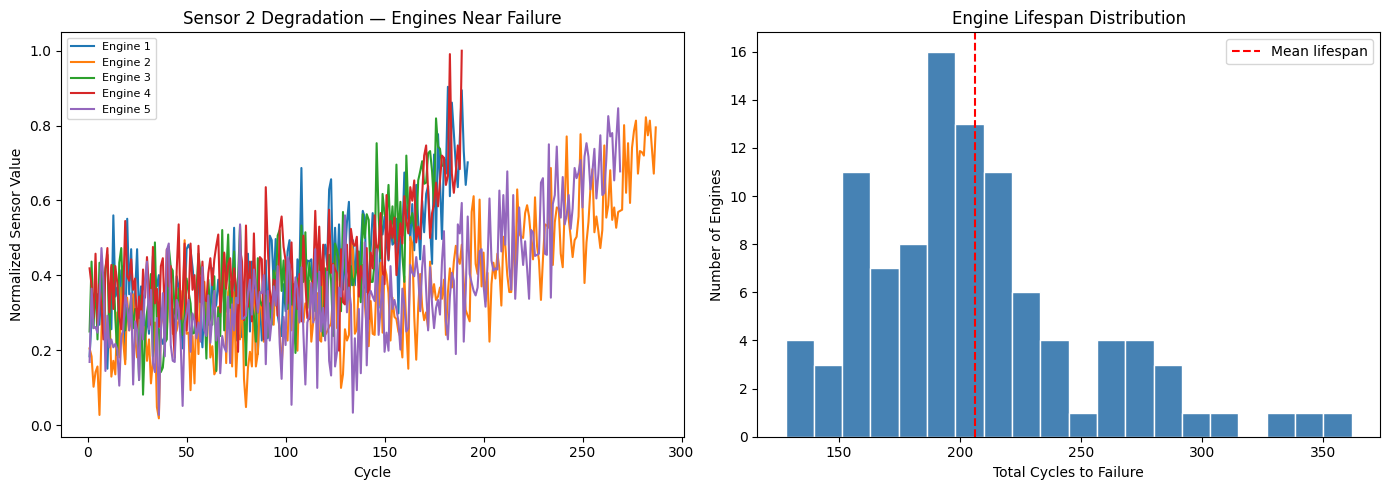

Chart saved to docs/


In [7]:
# Show sensor degradation for engines approaching failure
# Pick 5 engines with different RUL profiles
sensor_cols = [c for c in cmapss.columns if c.startswith("sensor_")]
useful = [s for s in sensor_cols if cmapss[s].std() > 0.01]

# Get engines with RUL between 0-100 for interesting stories
interesting_engines = cmapss[cmapss["rul"] <= 100]["engine_id"].unique()[:5]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sensor 2 trend for 5 engines — one of the strongest degradation signals
for eng_id in interesting_engines:
    eng_data = cmapss[cmapss["engine_id"] == eng_id].sort_values("cycle")
    axes[0].plot(eng_data["cycle"], eng_data["sensor_2"], 
                 label=f"Engine {int(eng_id)}", linewidth=1.5)

axes[0].set_title("Sensor 2 Degradation — Engines Near Failure")
axes[0].set_xlabel("Cycle")
axes[0].set_ylabel("Normalized Sensor Value")
axes[0].legend(fontsize=8)

# RUL distribution across all engines
rul_at_last_cycle = cmapss.groupby("engine_id")["rul"].min()
axes[1].hist(cmapss.groupby("engine_id")["cycle"].max(), 
             bins=20, color="steelblue", edgecolor="white")
axes[1].set_title("Engine Lifespan Distribution")
axes[1].set_xlabel("Total Cycles to Failure")
axes[1].set_ylabel("Number of Engines")
axes[1].axvline(x=cmapss.groupby("engine_id")["cycle"].max().mean(), 
                color="red", linestyle="--", label="Mean lifespan")
axes[1].legend()

plt.tight_layout()
plt.savefig("../docs/cmapss_degradation.png", dpi=150)
plt.show()
print("Chart saved to docs/")

In [8]:
import os
from pathlib import Path

print("Current directory:", os.getcwd())
print("Docs path exists:", Path("../docs").exists())
print("Files in docs:", list(Path("../docs").iterdir()) if Path("../docs").exists() else "EMPTY")

Current directory: C:\Users\kenwi\OneDrive\Desktop\opsiq\notebooks
Docs path exists: True
Files in docs: [WindowsPath('../docs/.gitkeep'), WindowsPath('../docs/cmapss_degradation.png'), WindowsPath('../docs/fleet_downtime_mtbf.png')]
